In [1]:
using CoulombIntegral

In [2]:
using SpecialFunctions
using FunctionZeros
using QuadGK
using LinearAlgebra
using Plots

In [3]:
sph_besselj(l,z) = z == 0 ? (l==0 ? 1.0 : 0.0) : besselj(l+1/2, z) * sqrt(π/2z);
function wfn(nl, R)
    n,l = nl;
    k = besselj_zero(l+1/2, n) / R;
    norm = sqrt(2/R^3) * sph_besselj(l+1, k*R)^(-1) * (-1)^(n-1);
    return ( (f = x -> norm * sph_besselj(l, k*x), k = k) ); # NamedTuple
end

wfn (generic function with 1 method)

In [4]:
function get_wfn!(nl, dict, R)
    haskey(dict, nl) && return dict[nl].f;
    wf = wfn(nl, R);
    dict[nl] = wf;
    return wf.f;
end

function get_kvec!(nl, dict, R)
    haskey(dict, nl) && return dict[nl].k;
    wf = wfn(nl, R);
    dict[nl] = wf;
    return wf.k;
end

get_kvec! (generic function with 1 method)

In [5]:
R1 = 1.0;
rwfns = Dict{Tuple,NamedTuple}() # (n,l) => (f=fun(x), k=k)

Dict{Tuple, NamedTuple}()

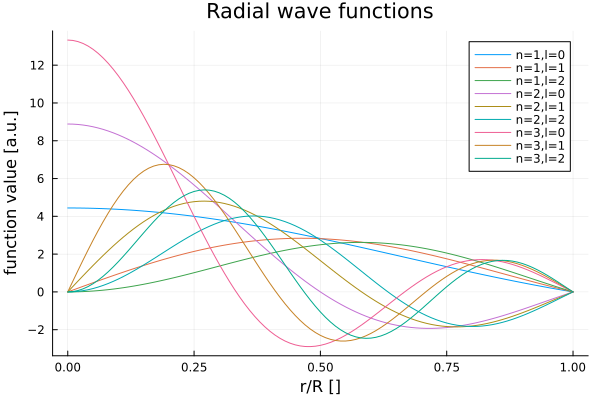

In [6]:
x = (0:0.01:R1);
p = plot(; xlabel="r/R []", ylabel="function value [a.u.]", title="Radial wave functions");
for n in 1:3
    for l in 0:2
        y = get_wfn!((n,l), rwfns, R1).(x);
        plot!(p,x,y; label="n=$n,l=$l");
    end
end
display(p)

In [7]:
for n in 1:3
    for l in 0:2
        int = quadgk(x->( x^2*get_wfn!( (n,l), rwfns, R1)(x)^2 ), 0, R1)[1];
        println("n: $n, l: $l, product: $int");
    end
end

n: 1, l: 0, product: 1.0
n: 1, l: 1, product: 1.00000000000002
n: 1, l: 2, product: 0.9999999999999998
n: 2, l: 0, product: 0.9999999999999922
n: 2, l: 1, product: 0.9999999999999908
n: 2, l: 2, product: 1.0000000000000169
n: 3, l: 0, product: 1.0000000000000164
n: 3, l: 1, product: 0.999999999999962
n: 3, l: 2, product: 0.9999999999999906


In [8]:
basis0 = [((1,0,0),(1,0,0)),       # |ss>
            ((1,1,-1),(1,1,-1)),   # |yy>
            ((1,1,0),(1,1,0)),     # |zz>
            ((1,1,1),(1,1,1))]     # |xx>

4-element Vector{Tuple{Tuple{Int64, Int64, Int64}, Tuple{Int64, Int64, Int64}}}:
 ((1, 0, 0), (1, 0, 0))
 ((1, 1, -1), (1, 1, -1))
 ((1, 1, 0), (1, 1, 0))
 ((1, 1, 1), (1, 1, 1))

In [9]:
b1 = [((1,0,0),(1,1,-1)),   # |sy>
      ((1,1,-1),(1,0,0)),   # |ys>
      ((1,0,0),(1,1,0)),    # |sz>
      ((1,1,0),(1,0,0)),    # |zs>
      ((1,0,0),(1,1,1)),    # |sx>
      ((1,1,1),(1,0,0))]    # |xs>

6-element Vector{Tuple{Tuple{Int64, Int64, Int64}, Tuple{Int64, Int64, Int64}}}:
 ((1, 0, 0), (1, 1, -1))
 ((1, 1, -1), (1, 0, 0))
 ((1, 0, 0), (1, 1, 0))
 ((1, 1, 0), (1, 0, 0))
 ((1, 0, 0), (1, 1, 1))
 ((1, 1, 1), (1, 0, 0))

In [10]:
coul0 = [coulomb_integral(Expand(), (nl)->get_wfn!(nl, rwfns, R1),fs...,is...; SH_basis=:real, recalc=true).int
    for fs in basis0, is in basis0]

integral estimate: 1.7860731721156868, error estimate: 2.6610102575516527e-8
integral estimate: 0.35965464220739163 - 0.0im, error estimate: 5.358183277702341e-9 - 0.0im
integral estimate: 0.3596546422073917, error estimate: 5.358183277702342e-9
integral estimate: 0.35965464220739163, error estimate: 5.358183277702341e-9
integral estimate: 0.3596546422073914 - 0.0im, error estimate: 5.3581832763684214e-9 - 0.0im
integral estimate: 1.670610996499229 - 0.0im, error estimate: 2.4890434902423687e-8 - 0.0im
integral estimate: 0.10904929259968314 - 0.0im, error estimate: 1.624767201995469e-9 - 0.0im
integral estimate: 0.10904929259968313 + 0.0im, error estimate: 1.624767201995469e-9 + 0.0im
integral estimate: 0.35965464220739146, error estimate: 5.358183276368422e-9
integral estimate: 0.10904929259968314 - 0.0im, error estimate: 1.624767201995469e-9 - 0.0im
integral estimate: 1.6706109964992295, error estimate: 2.4890434902423693e-8
integral estimate: 0.10904929259968314, error estimate: 1.6

4×4 Matrix{Number}:
         1.78607   0.359655-0.0im          0.359655          0.359655
 0.359655-0.0im     1.67061-0.0im  0.109049-0.0im    0.109049+0.0im
         0.359655  0.109049-0.0im          1.67061           0.109049
         0.359655  0.109049+0.0im          0.109049          1.67061

In [11]:
c1 = [coulomb_integral(Expand(), (nl)->get_wfn!(nl, rwfns, R1),fs...,is...; SH_basis=:real, recalc=true).int
    for fs in b1, is in b1]

integral estimate: -1.6196770421401854 + 0.0im, error estimate: -2.4126993822289086e-8 + 0.0im
integral estimate: -0.35965464220739185 + 0.0im, error estimate: -5.3581832779204985e-9 + 0.0im
integral estimate: 0, error estimate: 0
integral estimate: 0, error estimate: 0
integral estimate: 0, error estimate: 0
integral estimate: 0, error estimate: 0
integral estimate: -0.3596546422073921 + 0.0im, error estimate: -5.358183274642946e-9 + 0.0im
integral estimate: -1.6196770421419882 + 0.0im, error estimate: -2.4124542915131513e-8 + 0.0im
integral estimate: 0, error estimate: 0
integral estimate: 0, error estimate: 0
integral estimate: 0, error estimate: 0
integral estimate: 0, error estimate: 0
integral estimate: 0, error estimate: 0
integral estimate: 0, error estimate: 0
integral estimate: 1.6196770421401858, error estimate: 2.4126993822289093e-8
integral estimate: 0.3596546422073919, error estimate: 5.358183277920499e-9
integral estimate: 0, error estimate: 0
integral estimate: 0, error

6×6 Matrix{Number}:
  -1.61968+0.0im  -0.359655+0.0im  0         0         0         0
 -0.359655+0.0im   -1.61968+0.0im  0         0         0         0
          0                0       1.61968   0.359655  0         0
          0                0       0.359655  1.61968   0         0
          0                0       0         0         1.61968   0.359655
          0                0       0         0         0.359655  1.61968

In [12]:
basis1 = [  ((1,0,0),(1,1,1)),    # |sx>
            ((1,1,1),(1,0,0))]    # |xs>

2-element Vector{Tuple{Tuple{Int64, Int64, Int64}, Tuple{Int64, Int64, Int64}}}:
 ((1, 0, 0), (1, 1, 1))
 ((1, 1, 1), (1, 0, 0))

In [13]:
coul1 = [coulomb_integral(Expand(), (nl)->get_wfn!(nl, rwfns, R1),fs...,is...; SH_basis=:real, recalc=true).int
    for fs in basis1, is in basis1]

integral estimate: 1.6196770421401854, error estimate: 2.4126993822289086e-8
integral estimate: 0.35965464220739185, error estimate: 5.3581832779204985e-9
integral estimate: 0.3596546422073921, error estimate: 5.358183274642946e-9
integral estimate: 1.6196770421419882, error estimate: 2.4124542915131513e-8


2×2 Matrix{Float64}:
 1.61968   0.359655
 0.359655  1.61968

In [14]:
# <x|x|s> dipole moment
ap = 1/sqrt(3);
rp = quadgk(x->(x^3 * get_wfn!( (1,0), rwfns, R1)(x) * get_wfn!( (1,1), rwfns, R1)(x)), 0, R1)[1]
dip(A) = A*ap*rp;

In [15]:
const hbar = 1.055e-34; # J.s
const ec = 1.602e-19; # C
const perm0 = 8.855e-12; # F.m^(-1)
const gaas = 12.85 * perm0;
const m0 = 9.11e-31; # kg
const gamma = 1/(270e-15) * 1e-1; # s^(-1)

In [16]:
kin0(me, mh, A) = [fs==is ? ((hbar*get_kvec!((fs[1]), rwfns, R1))^2/(2me*m0*A^2)/ec + # eV
                             (hbar*get_kvec!((fs[2]), rwfns, R1))^2/(2mh*m0*A^2)/ec) : 0 for fs in basis0, is in basis0];

In [17]:
kin1(me, mh, A) = [fs==is ? ((hbar*get_kvec!((fs[1]), rwfns, R1))^2/(2me*m0*A^2)/ec + # eV
                             (hbar*get_kvec!((fs[2]), rwfns, R1))^2/(2mh*m0*A^2)/ec) : 0 for fs in basis1, is in basis1];

In [18]:
kin0(0.07,0.5,30e-9)

4×4 Matrix{Real}:
 0.00681017  0          0          0
 0           0.0139319  0          0
 0           0          0.0139319  0
 0           0          0          0.0139319

In [19]:
kin1(0.07,0.5,30e-9)

2×2 Matrix{Real}:
 0.00768477  0
 0           0.0130573

In [20]:
ham0(me, mh, A) = (kin0(me, mh, A) - ec*coul0/(4pi*gaas*A)); # eV
ham1(me, mh, A) = (kin1(me, mh, A) - ec*coul1/(4pi*gaas*A)); # eV

In [21]:
h0 = ham0(0.07, 0.5, 30e-9);
eval0,evec0 = LinearAlgebra.eigen(h0)

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
4-element Vector{Float64}:
 -0.0005851751573799019
  0.007603541636196444
  0.008100149959009139
  0.008100149959009139
vectors:
4×4 Matrix{Float64}:
 -0.954697  -0.297581  -6.1422e-17  -9.83696e-16
 -0.171808   0.551194  -0.57735     -0.696598
 -0.171808   0.551194   0.788675    -0.0205684
 -0.171808   0.551194  -0.211325     0.717167

In [22]:
h1 = ham1(0.07, 0.5, 30e-9);
eval1,evec1 = LinearAlgebra.eigen(h1)

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
2-element Vector{Float64}:
 0.0013189058932232935
 0.007325596045743925
vectors:
2×2 Matrix{Float64}:
 -0.973248   0.229756
 -0.229756  -0.973248

In [23]:
function mobility(f::Union{Real,Vector}, eval0::Vector, evec0::Matrix, eval1::Vector, evec1::Matrix, dip::Real)
    w = 2pi*1e12.*f; # rad.s^(-1)
    dip1 = dip*(evec0[1]-evec0[2])*(evec1[1]-evec1[2]); # m
    dip2 = dip*(evec0[1]-evec0[2])*(evec1[1]+evec1[2]); # m
    ediff1 = (eval1[1] - eval0[1])*ec; # J
    ediff2 = (eval1[2] - eval0[1])*ec; # J
    val =  1e4im .* w .* ec .* dip1^2 ./ (hbar.*w .- ediff1 .+ 1im*gamma*hbar); # cm^2.V^(-1).s^(-1)
    val += 1e4im .* w .* ec .* dip2^2 ./ (hbar.*w .- ediff2 .+ 1im*gamma*hbar); # cm^2.V^(-1).s^(-1)
    return val;
end

mobility (generic function with 1 method)

In [24]:
function mobility_non(f::Union{Real,Vector}, eval0::Vector, evec0::Matrix, eval1::Vector, evec1::Matrix, dip::Real)
    w = 2pi*1e12.*f; # rad.s^(-1)
    dip1 = dip; # m
    dip2 = dip; # m
    ediff1 = (eval1[1] - eval0[1])*ec; # J
    ediff2 = (eval1[2] - eval0[1])*ec; # J
    val =  1e4im .* w .* ec .* dip1^2 ./ (hbar.*w .- ediff1 .+ 1im*gamma*hbar); # cm^2.V^(-1).s^(-1)
    val += 1e4im .* w .* ec .* dip2^2 ./ (hbar.*w .- ediff2 .+ 1im*gamma*hbar); # cm^2.V^(-1).s^(-1)
    return val;
end

mobility_non (generic function with 1 method)

In [25]:
mres = 60;
wres = 100;
data_c = zeros(Float64, mres, wres);
data_n = zeros(Float64, mres, wres);
wmax = 3;
w = collect(0:wmax/(wres-1):wmax);

In [26]:
mtot = 0.067 + 0.47;
A1 = 25e-9; # 25 nm

In [27]:
for itr in 1:mres
    me = mtot * (0.9*(itr-1)/(mres-1) + 0.05);
    mh = mtot - me;
    h0 = ham0(me, mh, A1);
    eval0, evec0 = LinearAlgebra.eigen(h0);
    h1 = ham1(me, mh, A1);
    eval1, evec1 = LinearAlgebra.eigen(h1);
    data_c[itr,:] = mobility(w, eval0, evec0, eval1, evec1, dip(A1)) |> real;
end

In [28]:
for itr in 1:mres
    me = mtot * (0.9*(itr-1)/(mres-1) + 0.05);
    mh = mtot - me;
    h0 = kin0(me, mh, A1);
    eval0, evec0 = LinearAlgebra.eigen(h0);
    h1 = kin1(me, mh, A1);
    eval1, evec1 = LinearAlgebra.eigen(h1);
    data_n[itr,:] = mobility_non(w, eval0, evec0, eval1, evec1, dip(A1)) |> real;
end

In [29]:
m_vals = (0.05:0.9/(mres-1):0.95);

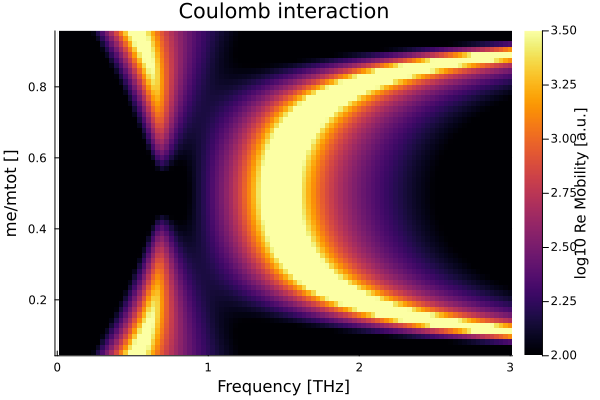

In [30]:
heatmap(w, m_vals, log10.(data_c); title="Coulomb interaction", clim=(2,3.5),
                        xlabel="Frequency [THz]", ylabel="me/mtot []", colorbar_title="log10 Re Mobility [a.u.]")

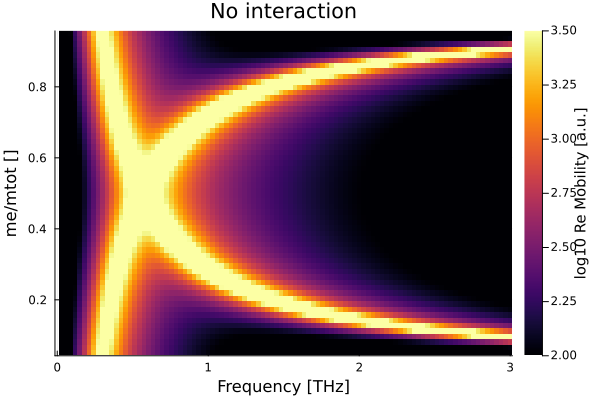

In [31]:
heatmap(w, m_vals, log10.(data_n); title="No interaction", clim=(2,3.5),
                        xlabel="Frequency [THz]", ylabel="me/mtot []", colorbar_title="log10 Re Mobility [a.u.]")